# 📊 Notebook 1: Data Exploration

## Learning Objectives
By the end of this notebook, you will:
- Download stock data from Yahoo Finance
- Understand OHLCV data structure
- Explore basic statistics
- Create visualizations
- Identify patterns and trends

## What You'll Learn
- How to use yfinance library
- Basic pandas operations
- Data visualization with matplotlib
- Understanding stock price data

---

## Setup

First, let's import all necessary libraries and our custom modules.

In [5]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Import our custom modules
import sys
import os
project_root = os.getcwd()
if project_root not in sys.path:
    sys.path.append(project_root)
import config
from src.data_collection import download_stock_data, load_stock_data

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## Step 1: Download Stock Data

Let's start by downloading historical stock data for Apple (AAPL).

**What is OHLCV data?**
- **O**pen: Price when market opens
- **H**igh: Highest price during the day
- **L**ow: Lowest price during the day
- **C**lose: Price when market closes
- **V**olume: Number of shares traded

In [6]:
# Define parameters
ticker = 'AAPL'
start_date = '2023-01-01'
end_date = '2024-01-01'

# Download data
print(f"Downloading {ticker} data from {start_date} to {end_date}...")
data = download_stock_data(ticker, start_date, end_date, save=True)

# Display first few rows
print(f"\n📈 Downloaded {len(data)} days of data")
data.head(10)

✅ Saved 250 rows to C:\Users\user\Desktop\Machine Learning Project\stock_ml_project\data\raw\AAPL_raw.csv
✅ Downloaded 250 days of data for AAPL

📈 Downloaded 250 days of data


Price,Date,Close,High,Low,Open,Volume,Ticker
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,
0,2023-01-03,123.096008,128.833987,122.210212,128.223777,112117500,AAPL
1,2023-01-04,124.365654,126.629356,123.105858,124.887288,89113600,AAPL
2,2023-01-05,123.046822,125.753419,122.790931,125.123520,80962700,AAPL
3,2023-01-06,127.574188,128.233612,122.918847,124.021172,87754700,AAPL
4,2023-01-09,128.095840,131.304398,127.839949,128.410797,70790800,AAPL
5,2023-01-10,128.666687,129.188321,126.097880,128.204104,63896200,AAPL
6,2023-01-11,131.383133,131.402806,128.400957,129.178481,69458900,AAPL
7,2023-01-12,131.304382,132.140958,129.365474,131.766965,71379600,AAPL
8,2023-01-13,132.633072,132.790550,129.582008,129.946164,57809700,AAPL


## Step 2: Basic Data Inspection

Let's examine the structure and quality of our data.

In [7]:
# Display info about the dataset
print("Dataset Information:")
print("="*50)
data.info()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype        
---  ------          --------------  -----        
 0   (Date, )        250 non-null    datetime64[s]
 1   (Close, AAPL)   250 non-null    float64      
 2   (High, AAPL)    250 non-null    float64      
 3   (Low, AAPL)     250 non-null    float64      
 4   (Open, AAPL)    250 non-null    float64      
 5   (Volume, AAPL)  250 non-null    int64        
 6   (Ticker, )      250 non-null    str          
dtypes: datetime64[s](1), float64(4), int64(1), str(1)
memory usage: 13.8 KB


In [8]:
# Statistical summary
print("\nStatistical Summary:")
print("="*50)
data.describe()


Statistical Summary:


Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
count,250,250.000000,250.000000,250.000000,250.000000,2.500000e+02
mean,2023-07-02 09:18:43,170.351416,171.642984,168.804714,170.063142,5.922355e+07
min,2023-01-03 00:00:00,123.046822,125.753419,122.210212,124.021172,2.404830e+07
25%,2023-04-03 06:00:00,159.797485,160.068570,158.405164,159.247964,4.781208e+07
50%,2023-07-04 00:00:00,173.442329,174.974356,171.826267,173.214989,5.511085e+07
75%,2023-10-01 06:00:00,185.253365,185.885949,182.783139,184.392090,6.574292e+07
max,2023-12-29 00:00:00,196.073090,197.567559,194.974519,195.984019,1.543573e+08
std,NaN,17.324154,17.256065,17.522306,17.519918,1.778332e+07


In [9]:
# Check for missing values
print("\nMissing Values:")
print("="*50)
missing = data.isnull().sum()
print(missing)

if missing.sum() == 0:
    print("\n✅ No missing values found!")
else:
    print("\n⚠️ Missing values detected")


Missing Values:
Price   Ticker
Date              0
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
Ticker            0
dtype: int64

✅ No missing values found!


## Step 3: Visualize Price Movement

Let's create visualizations to understand price trends.

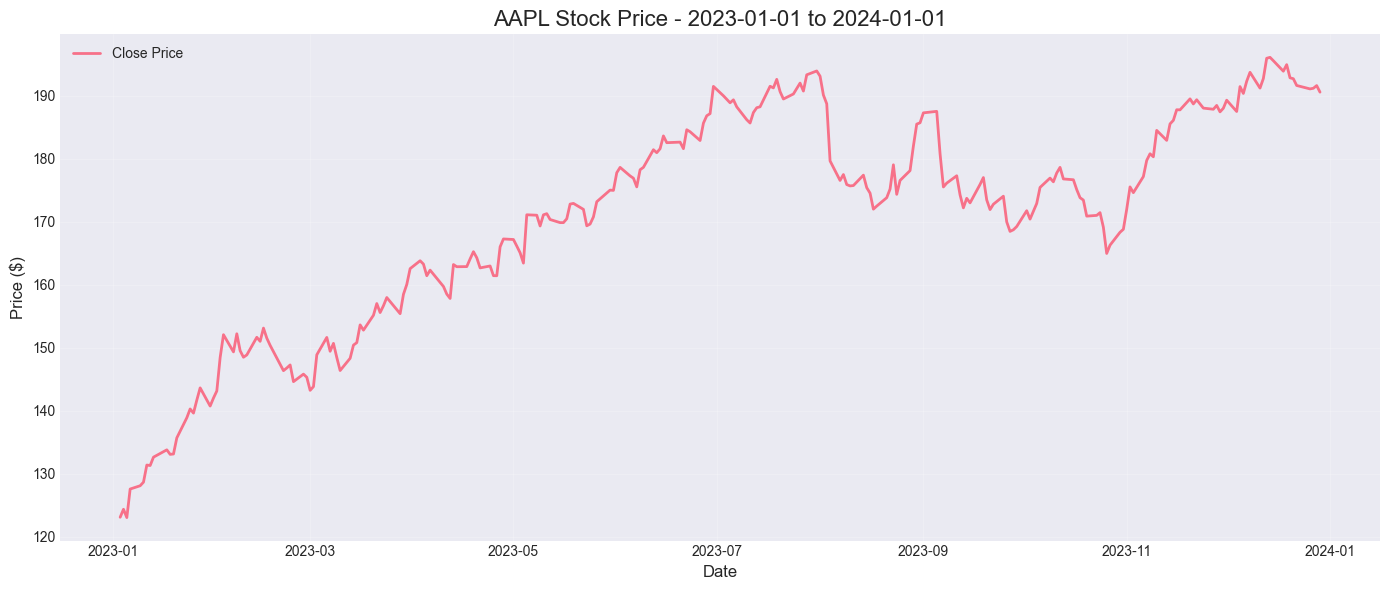

📊 Minimum price: $123.05
📊 Maximum price: $196.07
📊 Average price: $170.35


In [11]:
# Plot closing price over time
plt.figure(figsize=(14, 6))
plt.plot(data['Date'], data['Close'], linewidth=2, label='Close Price')
plt.title(f'{ticker} Stock Price - {start_date} to {end_date}', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"📊 Minimum price: ${data['Close'][ticker].min():.2f}")
print(f"📊 Maximum price: ${data['Close'][ticker].max():.2f}")
print(f"📊 Average price: ${data['Close'][ticker].mean():.2f}")

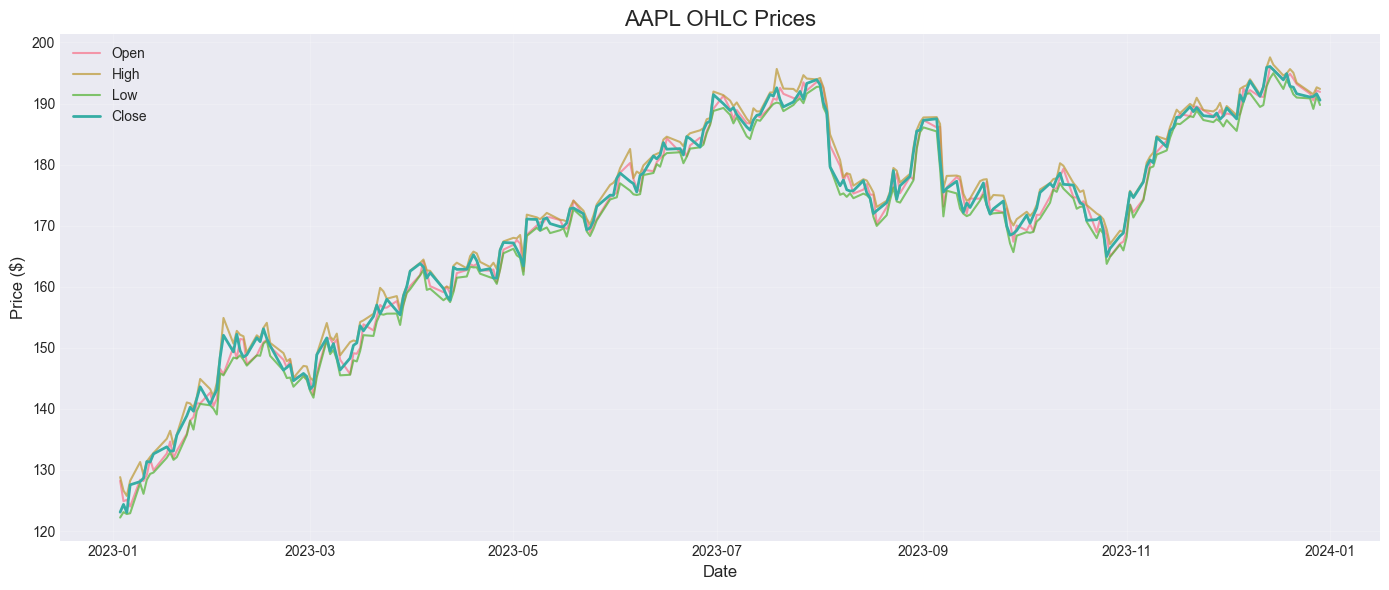

In [12]:
# Plot all OHLC prices
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(data['Date'], data['Open'], label='Open', alpha=0.7)
ax.plot(data['Date'], data['High'], label='High', alpha=0.7)
ax.plot(data['Date'], data['Low'], label='Low', alpha=0.7)
ax.plot(data['Date'], data['Close'], label='Close', linewidth=2)
ax.set_title(f'{ticker} OHLC Prices', fontsize=16)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price ($)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 4: Analyze Trading Volume

Volume shows how many shares were traded. High volume often accompanies significant price movements.

TypeError: only 0-dimensional arrays can be converted to Python scalars

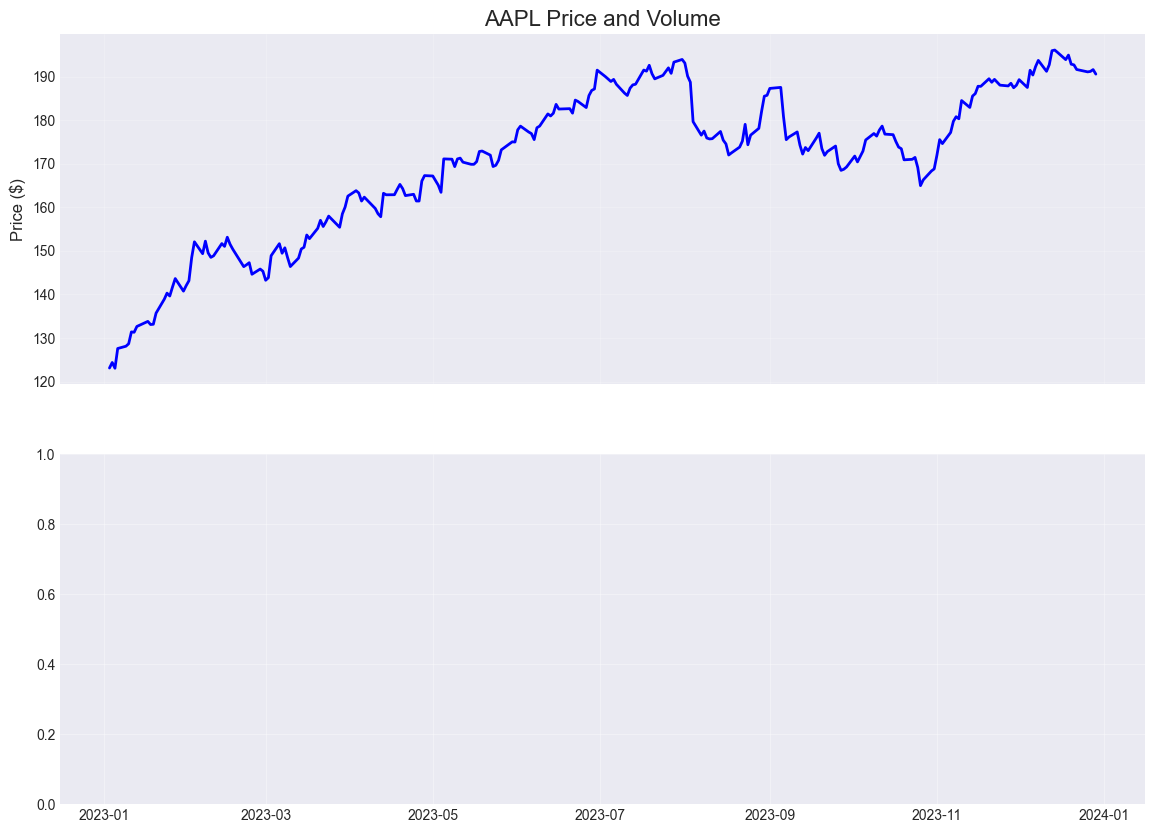

In [13]:
# Plot volume
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Price
ax1.plot(data['Date'], data['Close'], linewidth=2, color='blue')
ax1.set_title(f'{ticker} Price and Volume', fontsize=16)
ax1.set_ylabel('Price ($)', fontsize=12)
ax1.grid(True, alpha=0.3)

# Volume
ax2.bar(data['Date'], data['Volume'], alpha=0.7, color='orange')
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Volume', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"📊 Average daily volume: {data['Volume'].mean():,.0f} shares")
print(f"📊 Highest volume day: {data.loc[data['Volume'].idxmax(), 'Date'].strftime('%Y-%m-%d')}")

## Step 5: Calculate Daily Returns

Returns show the percentage change in price from one day to the next.

Daily Returns Statistics:
Mean daily return: 0.183%
Std deviation: 1.257%
Best day: 4.69%
Worst day: -4.80%


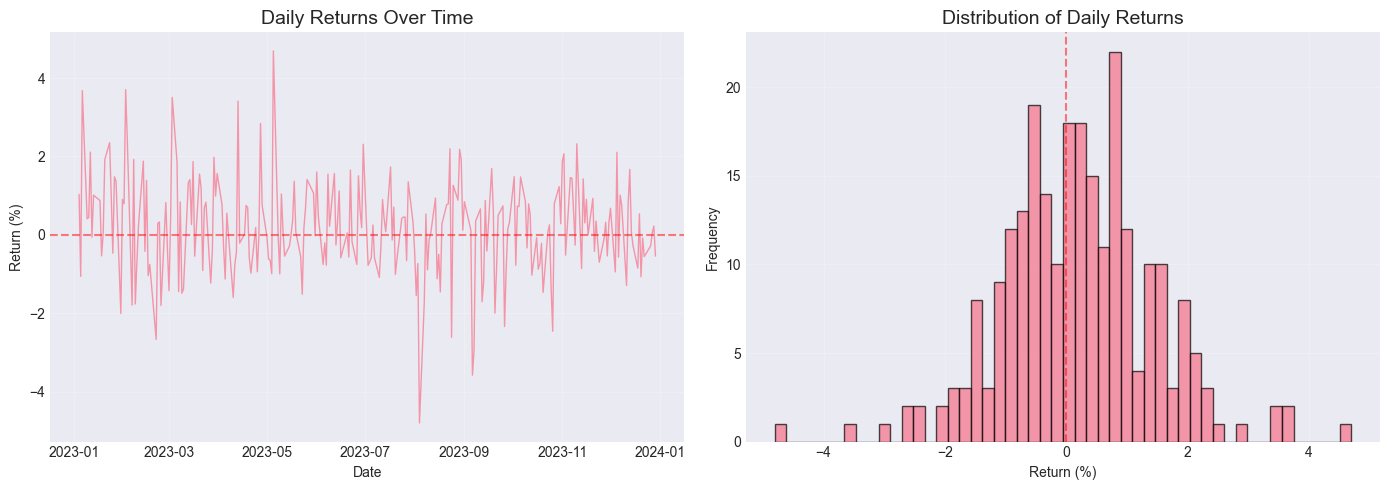

In [14]:
# Calculate daily returns
data['Returns'] = data['Close'].pct_change() * 100  # Convert to percentage

# Display statistics
print("Daily Returns Statistics:")
print("="*50)
print(f"Mean daily return: {data['Returns'].mean():.3f}%")
print(f"Std deviation: {data['Returns'].std():.3f}%")
print(f"Best day: {data['Returns'].max():.2f}%")
print(f"Worst day: {data['Returns'].min():.2f}%")

# Plot returns distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Returns over time
ax1.plot(data['Date'], data['Returns'], linewidth=1, alpha=0.7)
ax1.axhline(y=0, color='r', linestyle='--', alpha=0.5)
ax1.set_title('Daily Returns Over Time', fontsize=14)
ax1.set_xlabel('Date')
ax1.set_ylabel('Return (%)')
ax1.grid(True, alpha=0.3)

# Returns histogram
ax2.hist(data['Returns'].dropna(), bins=50, edgecolor='black', alpha=0.7)
ax2.axvline(x=0, color='r', linestyle='--', alpha=0.5)
ax2.set_title('Distribution of Daily Returns', fontsize=14)
ax2.set_xlabel('Return (%)')
ax2.set_ylabel('Frequency')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 6: Identify Up and Down Days

This is what we'll predict with our ML model!

Market Direction Analysis:
Up days: 140 (56.2%)
Down days: 108 (43.4%)


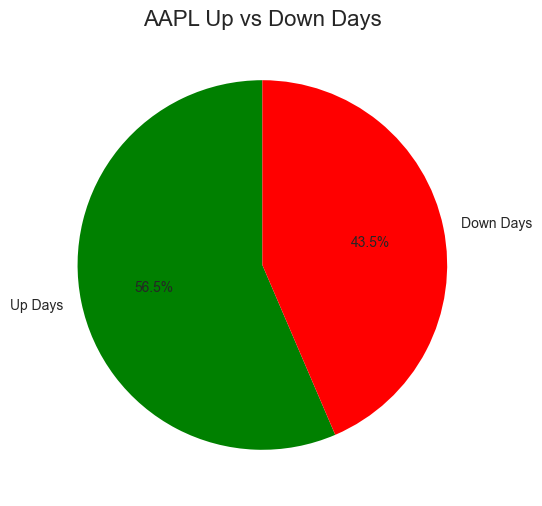


💡 Insight: If we randomly guessed, we'd be right 56.2% of the time.
Our ML model needs to beat this baseline!


In [15]:
# Count up and down days
up_days = (data['Returns'] > 0).sum()
down_days = (data['Returns'] < 0).sum()
total_days = len(data) - 1  # Minus 1 because first day has no return

print("Market Direction Analysis:")
print("="*50)
print(f"Up days: {up_days} ({up_days/total_days*100:.1f}%)")
print(f"Down days: {down_days} ({down_days/total_days*100:.1f}%)")

# Visualize
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['green', 'red']
ax.pie([up_days, down_days], labels=['Up Days', 'Down Days'], 
       autopct='%1.1f%%', colors=colors, startangle=90)
ax.set_title(f'{ticker} Up vs Down Days', fontsize=16)
plt.show()

print(f"\n💡 Insight: If we randomly guessed, we'd be right {max(up_days, down_days)/total_days*100:.1f}% of the time.")
print(f"Our ML model needs to beat this baseline!")

## 🎯 Exercise: Try It Yourself!

Modify the code above to:
1. Change the ticker to another stock (e.g., 'MSFT', 'GOOGL', 'TSLA')
2. Change the date range to a different period
3. Compare 2-3 stocks side by side

In [ ]:
# YOUR CODE HERE
# Try downloading and comparing multiple stocks

tickers = ['AAPL', 'MSFT', 'GOOGL']

# Download data for each
# Plot them on the same chart
# Compare their volatility


## 📝 Key Takeaways

1. **Stock data** consists of OHLCV values for each trading day
2. **Returns** show percentage change and are more useful than raw prices
3. **Volume** indicates trading activity and market interest
4. **Up/down distribution** is roughly 50/50 (markets are unpredictable!)
5. **Volatility** varies over time - some periods are more stable than others

## Next Steps

In Notebook 2, we'll engineer features from this raw data to make it more predictive!

---

**Questions to think about:**
- Why are stock prices so volatile?
- What might cause sudden spikes in volume?
- How can we use past price patterns to predict future movements?